# Лабораторная работа 5 
# Анимация качения треугольника рело по квадрату 


Космпьютерная математика 2, ММФ, БГУ


__Выполнил: Нестерук Кирилл__   
__Курс: 1__   
__Группа: 5__


In [2]:
import math 
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
def regular_polygon_Relo(
    n: int = 3,
    center: np.ndarray = np.array([0, 0]),
    r: float = 1.0,
    N: int = 100
) -> np.ndarray:
    """
    Возвращает матрицу точек границы правильного многоугольника Рело.

    Параметры:
    n : int (нечётное, >2) — количество вершин
    center : np.ndarray — центр фигуры [x, y]
    r : float — ширина фигуры (>0)
    N : int — количество точек на одну сторону (>0)

    Возвращает:
    np.ndarray — массив формы (n*N, 2) с координатами точек границы.
    """
    assert isinstance(n, int) and n > 2 and n % 2 == 1, "n должно быть нечётным целым >2"
    assert isinstance(center, np.ndarray) and center.shape == (2,), "center должен быть [x, y]"
    assert isinstance(r, (int, float)) and r > 0, "r > 0"
    assert isinstance(N, int) and N > 0, "N > 0"

    alpha = 2 * np.pi / n
    
    # ПРАВИЛЬНАЯ формула для радиуса описанной окружности
    R = r / (2 * np.sin(2 * np.pi / n))
    
    # Вершины правильного n-угольника (используем R, а не r!)
    t = np.arange(0, 2 * np.pi, alpha)
    vertices = center + R * np.transpose([np.cos(t), np.sin(t)])

    beta = alpha / 2
    angle = np.linspace(-beta / 2, beta / 2, N)

    list_sides = [
        vertices[i] + r * np.transpose([
            np.cos(angle + np.pi + i * alpha),
            np.sin(angle + np.pi + i * alpha)
        ])
        for i in range(n)
    ]

    return np.concatenate(list_sides)

In [5]:
n = 3 # количество вершин треугольника Рело
center = np.array([0.,0.]) # центр треугольника Рело
r = 10 # ширина треугольника Рело
N = 100 # количество точек для описания стороны треугольника Рело


In [7]:
relo_matrix = regular_polygon_Relo(r=r, center=center, N=N)

In [9]:
x_side = np.linspace(-5, 5, 100)
y_top = np.full_like(x_side, 5)
y_bottom = np.full_like(x_side, -5)

y_side = np.linspace(-5, 5, 100)
x_left = np.full_like(y_side, -5)
x_right = np.full_like(y_side, 5)

X = np.concatenate([x_side, x_side[::-1], x_left, x_right])
Y = np.concatenate([y_top, y_bottom[::-1], y_side, y_side[::-1]])

In [24]:
square = np.transpose([X,Y])
def make_square(r: float) -> np.ndarray:
    half = r / 2
    return np.array([
        [-half, -half],
        [ half, -half],
        [ half,  half],
        [-half,  half],
        [-half, -half]
    ])

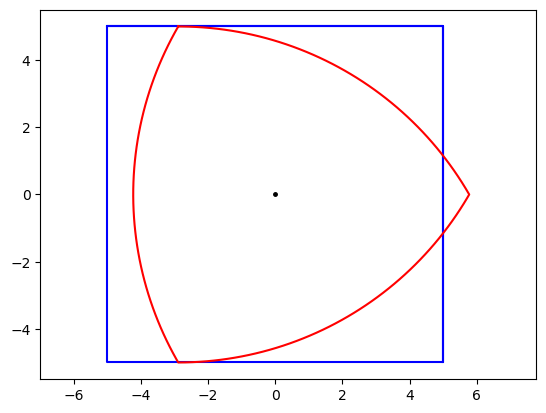

In [14]:

plt.plot(square[:,0],square[:,1],'b-')
plt.plot(relo_matrix[:,0],relo_matrix[:,1],'r-')
plt.plot(center[0],center[1],'k.',markersize=5)
plt.axis('equal');

In [15]:

shift = np.array([min(relo_matrix[:,0])-min(square[:,0]),0])
relo_matrix_shifted = relo_matrix - shift
center -= shift

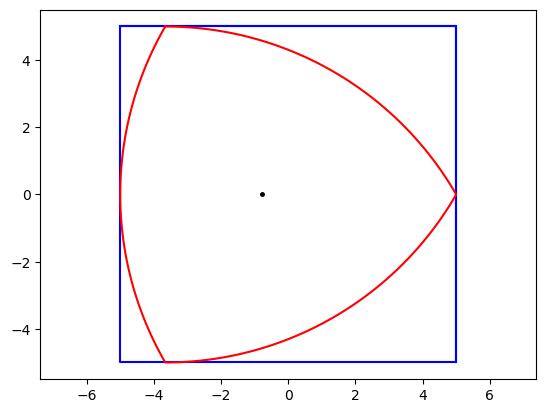

In [16]:
plt.plot(square[:,0],square[:,1],'b-')
plt.plot(relo_matrix_shifted[:,0],relo_matrix_shifted[:,1],'r-')
plt.plot(center[0],center[1],'k.',markersize=5)
plt.axis('equal');

## Задание 5.2

In [17]:
N_frames = 100

In [18]:
t_center = np.linspace(-np.pi, np.pi, N_frames)
center_frame = shift[0]*np.transpose([np.cos(t_center), np.sin(t_center)])


In [19]:
frame = 0
relo_matrix_shifted = relo_matrix + center_frame[frame]


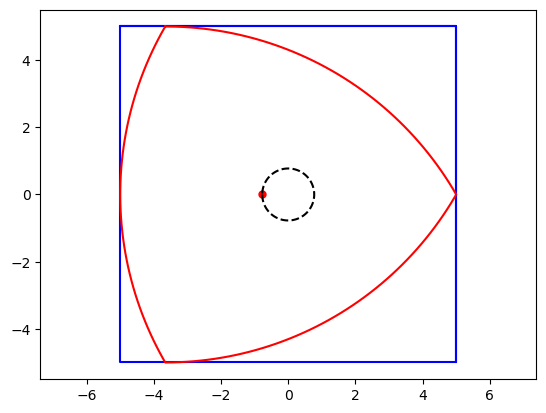

In [21]:
plt.figure()
plt.plot(square[:,0],square[:,1],'b-')
plt.plot(relo_matrix_shifted[:,0],relo_matrix_shifted[:,1],'r-')
plt.plot(center_frame[frame,0],center_frame[frame,1],'r.',markersize=10)
plt.plot(center_frame[:,0],center_frame[:,1],'k--')
plt.axis('equal');

In [26]:
def draw_frame(
    r:float, 
    N_frames:int,
    frame:int = 0
) -> np.ndarray:
    """
    изображает кадр с номером frame при поступательном движении центра треугольника
    Рело по окружности против часовой стрелки.

    Параметры
    ---------
    r: задает ширину треугольника Рело.
    N_frames: задает количество кадров для прохождения центром
    треугольника Рело полной окружности.
    frame: задает номер кадра; по умолчанию frame=0 .

    Возвращает
    ----------
    Функция осуществляет визуализацию и не возвращает объекты.
    """
    center = np.array([0.0,0.0])
    Relo2=regular_polygon_Relo(r=r, center=center, N=N)

    x_side1 = np.linspace(-r/2, r/2, N)
    y_top1 = np.full_like(x_side, r/2)
    y_bottom1 = np.full_like(x_side, -r/2)
    
    y_side1 = np.linspace(-r/2, r/2, N)
    x_left1 = np.full_like(y_side, -r/2)
    x_right1 = np.full_like(y_side, r/2)
    
    X1 = np.concatenate([x_side1, x_side1[::-1], x_left1, x_right1])
    Y1= np.concatenate([y_top1, y_bottom1[::-1], y_side1, y_side1[::-1]])

    square1 = np.transpose([X1,Y1])
    
    shift1 = np.array([min(Relo2[:,0])-min(square1[:,0]),0])
    relo_matrix_shifted1 = Relo2 - shift1
    center -= shift1

    t_center1 = np.linspace(-np.pi, np.pi, N_frames)
    center_frame1 = shift[0]*np.transpose([np.cos(t_center1), np.sin(t_center1)])

    relo_matrix_shifted = relo_matrix + center_frame[frame]

    plt.plot(square[:,0],square[:,1],'b-')
    plt.plot(relo_matrix_shifted[:,0],relo_matrix_shifted[:,1],'r-')
    plt.plot(center_frame[frame,0],center_frame[frame,1],'r.',markersize=10)
    plt.plot(center_frame[:,0],center_frame[:,1],'k--')
    plt.axis('equal');

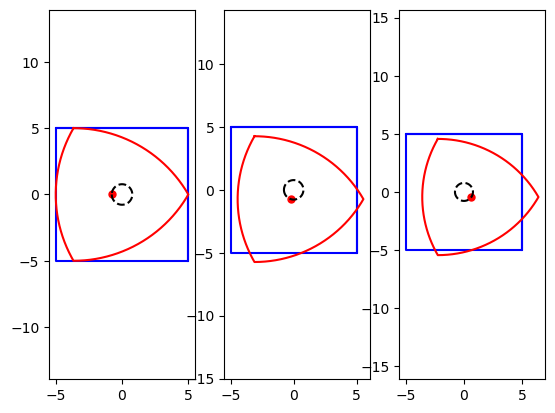

In [27]:
plt.figure()

N_frames = 100

plt.subplot(1,3,1)
draw_frame(r=10, N_frames=N_frames)

plt.subplot(1,3,2)
draw_frame(r=10, N_frames=N_frames, frame=20)

plt.subplot(1,3,3)
draw_frame(r=10, N_frames=N_frames, frame=40)

plt.show()

## Задание 5.3

In [29]:
rotate_matrix = lambda theta: np.array([[np.cos(theta), np.sin(theta)],
 [-np.sin(theta), np.cos(theta)]])
rotate_matrix(np.pi)


array([[-1.0000000e+00,  1.2246468e-16],
       [-1.2246468e-16, -1.0000000e+00]])

In [30]:
theta = np.pi/3
matrix = rotate_matrix(theta)
relo_matrix_rotated = np.array([np.dot(matrix,row) for row in relo_matrix])

In [31]:
print(matrix)

[[ 0.5        0.8660254]
 [-0.8660254  0.5      ]]


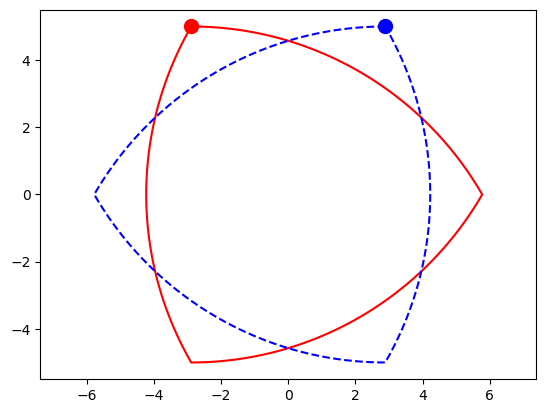

In [33]:
plt.figure()
plt.plot(relo_matrix[:,0],relo_matrix[:,1],'r-')
plt.plot(relo_matrix[0,0],relo_matrix[0,1],'r.',markersize=20)
plt.plot(relo_matrix_rotated[:,0],relo_matrix_rotated[:,1],'b--')
plt.plot(relo_matrix_rotated[0,0],relo_matrix_rotated[0,1],'b.',markersize=20)
plt.axis('equal');

In [34]:
theta = np.linspace(0, 2*np.pi/3, N_frames)

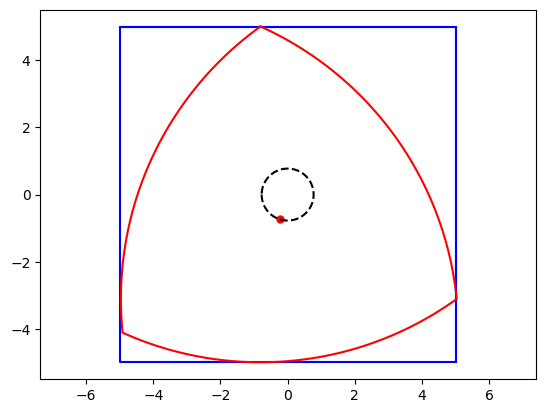

In [35]:
frame = 20
matrix = rotate_matrix(theta[frame])
relo_matrix_changed = (np.array([np.dot(matrix,row) for row in relo_matrix])
 + center_frame[frame])
plt.figure()
plt.plot(square[:,0],square[:,1],'b-')
plt.plot(relo_matrix_changed[:,0],relo_matrix_changed[:,1],'r-')
plt.plot(center_frame[frame,0],center_frame[frame,1],'r.',markersize=10)
plt.plot(center_frame[:,0],center_frame[:,1],'k--')
plt.axis('equal');


In [36]:
def draw_frame(
    r:float,
    N_frames:int,
    frame:int = 0
) -> None:
    """
    изображает кадр с номером frame при поступательном движении центра треугольника
    Рело по окружности против часовой стрелки и  вращательное движение по часовой стрелке

    Параметры
    ---------
    r: задает ширину треугольника Рело.
    N_frames: задает количество кадров для прохождения центром
    треугольника Рело полной окружности.
    frame: задает номер кадра; по умолчанию frame=0 .

    Возвращает
    ----------
    Функция осуществляет визуализацию и не возвращает объекты.
    """
    N = 100
    center = np.array([0.0,0.0])
    Relo2 = regular_polygon_Relo(r=r, center=center, N=N)

    x_side = np.linspace(-r/2, r/2, N)
    y_top = np.full_like(x_side, r/2)
    y_bottom = np.full_like(x_side, -r/2)

    y_side = np.linspace(-r/2, r/2, N)
    x_left = np.full_like(y_side, -r/2)
    x_right = np.full_like(y_side, r/2)

    X1 = np.concatenate([x_side, x_side[::-1], x_left, x_right])
    Y1 = np.concatenate([y_top, y_bottom[::-1], y_side, y_side[::-1]])

    square1 = np.transpose([X1,Y1])

    shift1 = np.array([min(Relo2[:,0])-min(square1[:,0]),0])
    relo_matrix_shifted1 = Relo2 - shift1
    center -= shift1

    t_center1 = np.linspace(-np.pi, np.pi, N_frames)
    center_frame1 = shift1[0]*np.transpose([np.cos(t_center1), np.sin(t_center1)])

    theta_arr = np.linspace(0, 2*np.pi/3, N_frames)

    rotate_matrix = lambda theta: np.array([[np.cos(theta), np.sin(theta)],
                                            [-np.sin(theta), np.cos(theta)]])
    matrix = rotate_matrix(theta_arr[frame])
    relo_matrix_changed = (np.array([np.dot(matrix, row) for row in relo_matrix_shifted1])
                           +center_frame1[frame])

    plt.plot(square1[:,0], square1[:,1], 'b-')
    plt.plot(relo_matrix_changed[:,0], relo_matrix_changed[:,1], 'r-')
    plt.plot(center_frame1[frame,0], center_frame1[frame,1], 'r.', markersize=10)
    plt.plot(center_frame1[:,0], center_frame1[:,1], 'k--')
    plt.axis('equal')

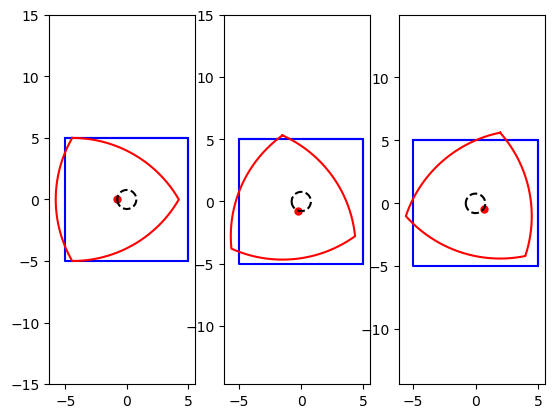

In [37]:
plt.figure()
plt.subplot(1,3,1)
draw_frame(r=r, N_frames=N_frames)
plt.subplot(1,3,2)
draw_frame(r=r, N_frames=N_frames, frame=20)
plt.subplot(1,3,3)
draw_frame(r=r, N_frames=N_frames, frame=40)